# Análisis de formación táctica

Extrae la formación de cada equipo del CSV de tracking completo usando **KMeans 2D sobre posiciones medianas por GID**.
Robusto ante la fragmentación de IDs típica de un partido de 45 minutos.

## Requisitos externos
- **`data/tracking_match.csv`** — CSV completo del partido generado por el pipeline (pestaña Exportar del dashboard o `process_segment()`). El análisis de formación requiere al menos 15-20 minutos de partido para que las posiciones medianas sean representativas.
- `pipeline_core.py` debe estar en el directorio de trabajo (`sys.path.insert(0, '.')` ya está configurado).

In [1]:
%matplotlib inline
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, '.')
from pipeline_core import extract_formation_from_csv, L_M, A_M

import os as _os
CSV_PATH          = 'data/tracking_match.csv'
if not _os.path.exists(CSV_PATH):
    CSV_PATH = 'data/example_banyoles/tracking_sample.csv'
    print(f'Usando CSV de ejemplo: {CSV_PATH}')
HOME_ATTACKS_LEFT = True   # Banyoles defiende a la derecha → ataca hacia x bajas
HALFTIME_FRAME    = None   # CSV solo contiene la primera parte
MIN_FRAMES        = 200    # mínimo de apariciones para incluir un GID

df = pd.read_csv(CSV_PATH)
print(f"CSV: {len(df):,} filas  |  {df['gid'].nunique()} GIDs  |  "
      f"frames {df['frame'].min()}–{df['frame'].max()}  "
      f"(~{(df['frame'].max()-df['frame'].min())/29.97/60:.1f} min)")
print(df['cls'].value_counts().to_string())

CSV: 1,488,548 filas  |  1002 GIDs  |  frames 7194–88110  (~45.0 min)
cls
player_home    647590
player_away    611982
referee         78923
gk_away         68265
gk_home         64223
unknown         17565


In [2]:
from pipeline_core import extract_formation_density

# ── Extraer formación por mapa de densidad ───────────────────────────────
form_home, centers_home = extract_formation_density(
    df, team='home', field_length=L_M, field_width=A_M,
    home_attacks_left=HOME_ATTACKS_LEFT,
    halftime_frame=HALFTIME_FRAME,
    speed_max=4.0,          # filtra sprints; 0 = sin filtro
    bins=(60, 37),
    sigma=2.5,
    suppress_radius_m=8.0,
)
form_away, centers_away = extract_formation_density(
    df, team='away', field_length=L_M, field_width=A_M,
    home_attacks_left=HOME_ATTACKS_LEFT,
    halftime_frame=HALFTIME_FRAME,
    speed_max=4.0,
    bins=(60, 37),
    sigma=2.5,
    suppress_radius_m=8.0,
)

print(f"Formación local:     {form_home}")
print(f"Formación visitante: {form_away}")
print()
print("Posiciones local (x_norm=0 portería propia, 1=portería contraria):")
print(centers_home.to_string(index=False))
print()
print("Posiciones visitante:")
print(centers_away.to_string(index=False))

Formación local:     5-3-2
Formación visitante: 5-3-2

Posiciones local (x_norm=0 portería propia, 1=portería contraria):
  x_norm       y_m  line role
0.491667 25.554054     0  DEF
0.508333 33.797297     0  DEF
0.525000 60.175676     0  DEF
0.541667 50.283784     0  DEF
0.541667 42.040541     0  DEF
0.558333 17.310811     0  DEF
0.575000 25.554054     0  DEF
0.591667 33.797297     0  DEF
0.675000 28.851351     1  MED
0.758333 28.851351     2  DEL

Posiciones visitante:
  x_norm       y_m  line role
0.425000 33.797297     0  DEF
0.425000 42.040541     0  DEF
0.458333 25.554054     0  DEF
0.491667 56.878378     0  DEF
0.508333 48.635135     0  DEF
0.508333 35.445946     0  DEF
0.541667 27.202703     0  DEF
0.591667 35.445946     1  MED
0.591667 43.689189     1  MED
0.625000 27.202703     2  DEL


Portero local:     x=87.2m  y=30.6m
Portero visitante: x=14.3m  y=31.2m


C:\Users\xavia\AppData\Local\Temp\ipykernel_34908\1204196656.py:92: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\xavia\Documents\GitHub\tfg-cv\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


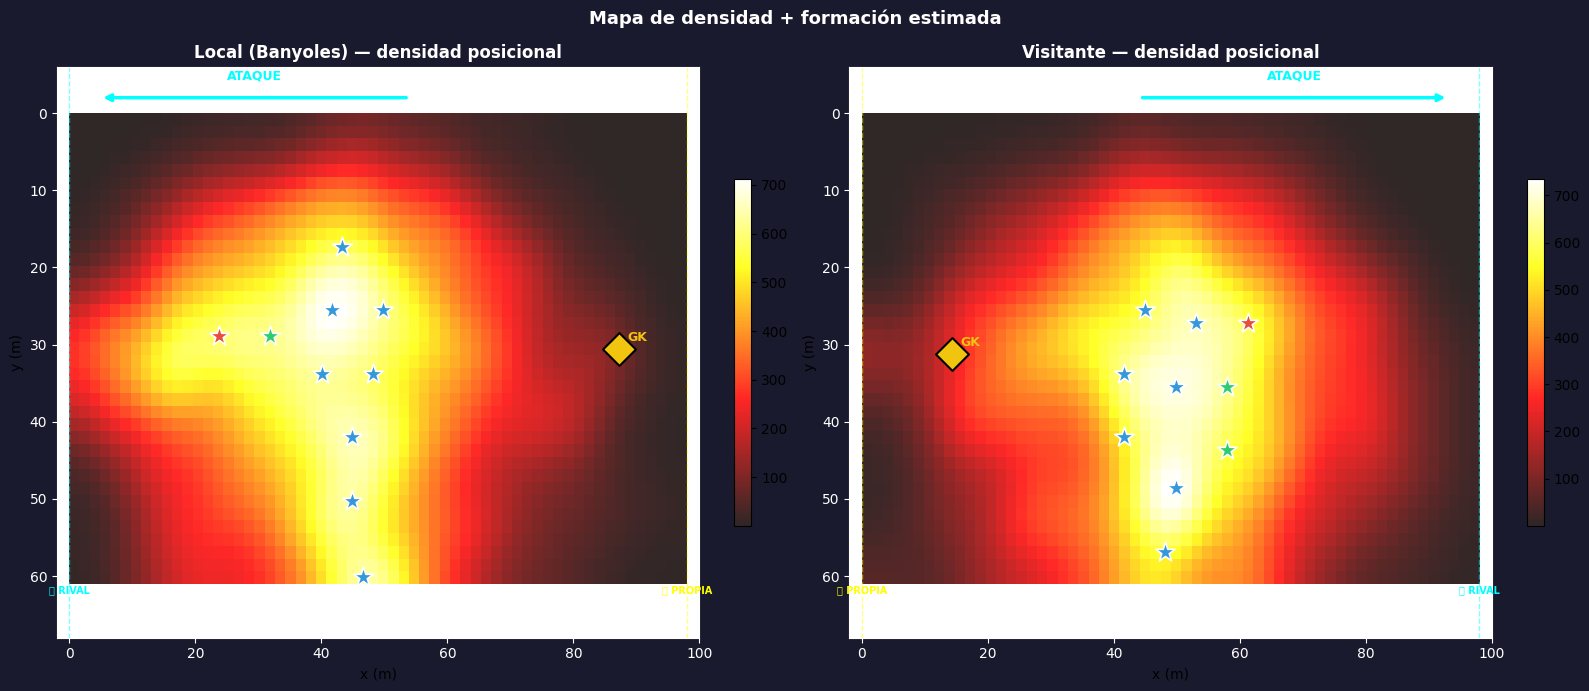

In [3]:
%matplotlib inline
# ── Heatmap de densidad con portero y dirección de ataque ────────────────
from pipeline_core import _x_norm_series
from scipy.ndimage import gaussian_filter

LINE_COLORS = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Posición mediana del portero (coordenadas absolutas del campo)
gk_home_pos = df[df['cls'] == 'gk_home'][['x_m', 'y_m']].median()
gk_away_pos = df[df['cls'] == 'gk_away'][['x_m', 'y_m']].median()
print(f"Portero local:     x={gk_home_pos['x_m']:.1f}m  y={gk_home_pos['y_m']:.1f}m")
print(f"Portero visitante: x={gk_away_pos['x_m']:.1f}m  y={gk_away_pos['y_m']:.1f}m")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1a1a2e')

configs = [
    ('Local (Banyoles)',  'player_home', True,  gk_home_pos, centers_home),
    ('Visitante',         'player_away', False, gk_away_pos, centers_away),
]

for ax, (team_lbl, player_cls, is_home, gk_pos, centers) in zip(axes, configs):

    sub = df[df['cls'] == player_cls].copy()
    if 'speed_ms' in sub.columns:
        sub = sub[sub['speed_ms'] <= 4.0]

    xn = _x_norm_series(sub['x_m'], sub['frame'],
                        is_home, HOME_ATTACKS_LEFT, HALFTIME_FRAME, L_M)
    sub = sub.copy(); sub['xn'] = xn

    if is_home and HOME_ATTACKS_LEFT:
        x_hist = (L_M - sub['xn']).clip(0, L_M)
    else:
        x_hist = sub['xn'].clip(0, L_M)

    H, xe, ye = np.histogram2d(
        x_hist, sub['y_m'].clip(0, A_M),
        bins=(60, 37), range=[[0, L_M], [0, A_M]])
    H_s = gaussian_filter(H.T.astype(float), sigma=2.5)

    # origin='lower' + ylim invertido → y=0 arriba (igual que coords de imagen)
    im = ax.imshow(H_s, origin='lower', aspect='auto',
                   extent=[0, L_M, 0, A_M], cmap='hot', alpha=0.85)
    plt.colorbar(im, ax=ax, fraction=0.025)

    if not centers.empty:
        if is_home and HOME_ATTACKS_LEFT:
            x_abs = (1 - centers['x_norm'].values) * L_M
        else:
            x_abs = centers['x_norm'].values * L_M
        for xi, yi, line in zip(x_abs, centers['y_m'], centers['line']):
            ax.scatter(xi, yi, s=220, color=LINE_COLORS[int(line) % 4],
                       marker='*', edgecolors='white', linewidths=1.2, zorder=6)

    if not gk_pos.isna().any():
        ax.scatter(gk_pos['x_m'], gk_pos['y_m'], s=280, color='#f1c40f',
                   marker='D', edgecolors='black', linewidths=1.5, zorder=7)
        ax.annotate('GK', (gk_pos['x_m'], gk_pos['y_m']),
                    textcoords='offset points', xytext=(6, 6),
                    color='#f1c40f', fontsize=9, fontweight='bold')

    if is_home and HOME_ATTACKS_LEFT:
        atk_x0, atk_x1 = L_M * 0.55, L_M * 0.05
        goal_own, goal_opp = L_M, 0
    else:
        atk_x0, atk_x1 = L_M * 0.45, L_M * 0.95
        goal_own, goal_opp = 0, L_M

    # Flecha ARRIBA del campo → y negativa (eje y invertido: y=0 arriba)
    ax.annotate('', xy=(atk_x1, -2), xytext=(atk_x0, -2),
                xycoords='data', textcoords='data',
                arrowprops=dict(arrowstyle='->', color='cyan', lw=2.5))
    ax.text((atk_x0 + atk_x1) / 2, -4, 'ATAQUE',
            ha='center', va='bottom', color='cyan', fontsize=9, fontweight='bold')
    ax.axvline(goal_own, color='yellow', lw=1, linestyle='--', alpha=0.5)
    ax.axvline(goal_opp, color='cyan',   lw=1, linestyle='--', alpha=0.5)
    ax.text(goal_own, A_M + 1.5, ' PROPIA', ha='center', va='bottom',
            color='yellow', fontsize=7, fontweight='bold')
    ax.text(goal_opp, A_M + 1.5, ' RIVAL', ha='center', va='bottom',
            color='cyan',   fontsize=7, fontweight='bold')

    # Eje y invertido: y=0 arriba (igual que coordenadas de imagen/tracking)
    ax.set_xlim(-2, L_M + 2); ax.set_ylim(A_M + 7, -6)
    ax.set_title(f'{team_lbl} — densidad posicional', color='white', fontweight='bold')
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('white')

plt.suptitle('Mapa de densidad + formación estimada', fontsize=13,
             color='white', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\xavia\AppData\Local\Temp\ipykernel_34908\3324179909.py:88: UserWarning: Glyph 129349 (\N{GOAL NET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xavia\AppData\Local\Temp\ipykernel_34908\3324179909.py:89: UserWarning: Glyph 129349 (\N{GOAL NET}) missing from font(s) DejaVu Sans.
  plt.savefig('formacion_tactica.png', dpi=150, bbox_inches='tight',
c:\Users\xavia\Documents\GitHub\tfg-cv\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129349 (\N{GOAL NET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


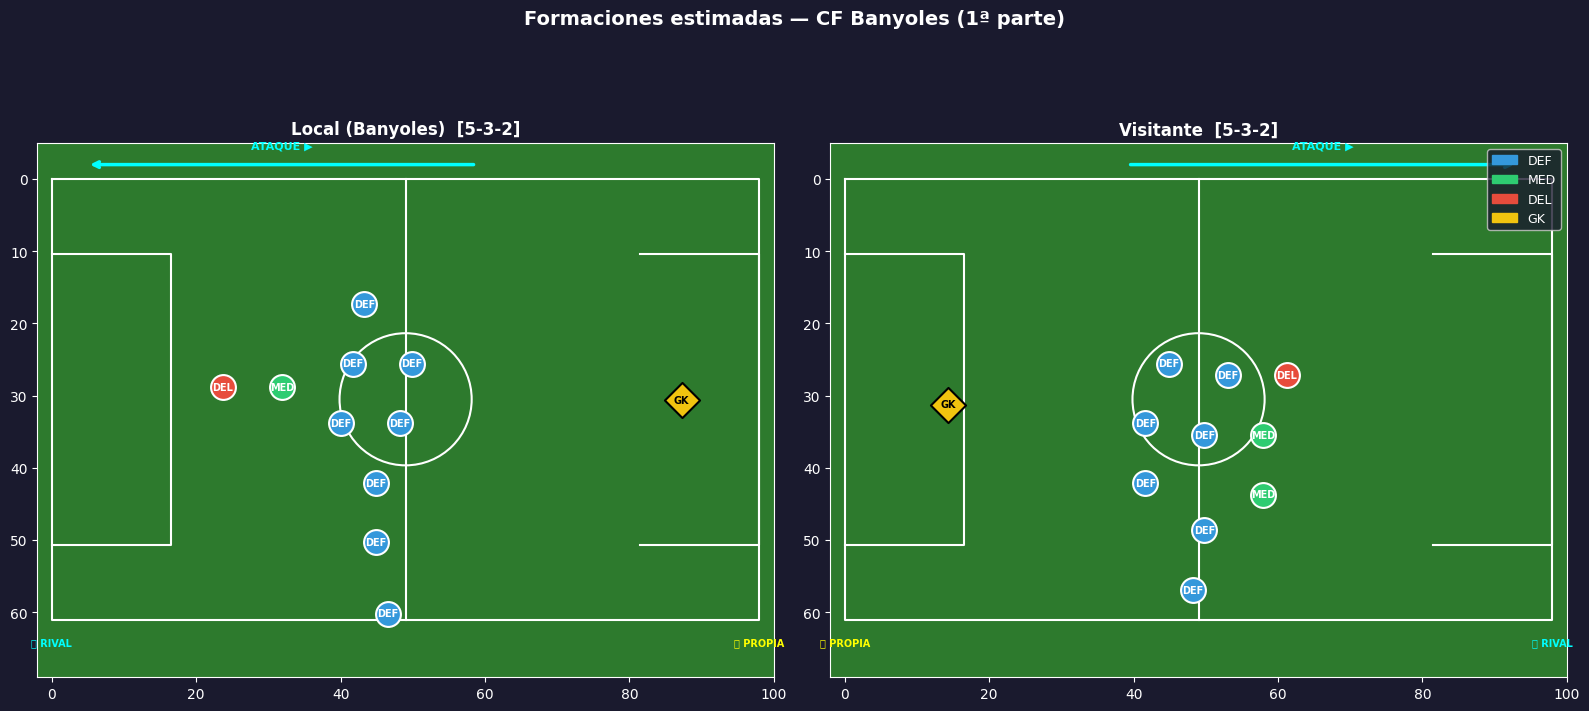

Guardado: formacion_tactica.png


In [4]:
%matplotlib inline
# ── Visualización de formaciones en el campo (coordenadas absolutas) ─────
def draw_pitch(ax, field_length=L_M, field_width=A_M):
    ax.set_facecolor('#2d7a2d')
    ax.set_xlim(-2, field_length + 2)
    ax.set_ylim(field_width + 8, -5)   # eje y invertido: y=0 arriba (coords imagen)
    ax.set_aspect('equal')
    kw = dict(color='white', linewidth=1.5)
    ax.plot([0, field_length, field_length, 0, 0],
            [0, 0, field_width, field_width, 0], **kw)
    ax.plot([field_length/2]*2, [0, field_width], **kw)
    ax.add_patch(plt.Circle((field_length/2, field_width/2), 9.15, fill=False, **kw))
    for x0, w in [(0, 16.5), (field_length - 16.5, 16.5)]:
        y0 = (field_width - 40.32) / 2
        ax.plot([x0, x0+w, x0+w, x0], [y0, y0, y0+40.32, y0+40.32], **kw)


def plot_formation_abs(ax, centers_df, formation, team_label, is_home,
                       home_attacks_left, gk_pos, field_length=L_M, field_width=A_M):
    if centers_df.empty:
        return

    if is_home and home_attacks_left:
        x_abs = (1 - centers_df['x_norm'].values) * field_length
        atk_x0, atk_x1 = field_length * 0.6, field_length * 0.05
        goal_own, goal_opp = field_length, 0
    else:
        x_abs = centers_df['x_norm'].values * field_length
        atk_x0, atk_x1 = field_length * 0.4, field_length * 0.95
        goal_own, goal_opp = 0, field_length

    y_abs = centers_df['y_m'].values

    for xi, yi, line, role in zip(x_abs, y_abs, centers_df['line'], centers_df['role']):
        col = LINE_COLORS[int(line) % 4]
        ax.scatter(xi, yi, s=320, color=col, marker='o',
                   edgecolors='white', linewidths=1.5, zorder=5)
        ax.text(xi, yi, role, ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=6)

    if gk_pos is not None and not gk_pos.isna().any():
        ax.scatter(gk_pos['x_m'], gk_pos['y_m'], s=320, color='#f1c40f',
                   marker='D', edgecolors='black', linewidths=1.5, zorder=5)
        ax.text(gk_pos['x_m'], gk_pos['y_m'], 'GK', ha='center', va='center',
                fontsize=7, color='black', fontweight='bold', zorder=6)

    # Flecha ARRIBA del campo → y negativa (eje y invertido: y=0 arriba)
    ax.annotate('', xy=(atk_x1, -2), xytext=(atk_x0, -2),
                arrowprops=dict(arrowstyle='->', color='cyan', lw=2.5))
    ax.text((atk_x0 + atk_x1)/2, -4, 'ATAQUE ▶',
            ha='center', va='bottom', color='cyan', fontsize=8, fontweight='bold')

    # Etiquetas portería → DEBAJO del campo (y > field_width, con eje invertido)
    ax.text(goal_own, field_width + 2.5, ' PROPIA', ha='center', va='top',
            color='yellow', fontsize=7, fontweight='bold')
    ax.text(goal_opp, field_width + 2.5, ' RIVAL', ha='center', va='top',
            color='cyan',   fontsize=7, fontweight='bold')

    ax.set_title(f'{team_label}  [{formation}]', fontsize=12,
                 fontweight='bold', color='white', pad=6)


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    draw_pitch(ax)
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('white')

plot_formation_abs(axes[0], centers_home, form_home,
                   'Local (Banyoles)', is_home=True,
                   home_attacks_left=HOME_ATTACKS_LEFT,
                   gk_pos=gk_home_pos)
plot_formation_abs(axes[1], centers_away, form_away,
                   'Visitante', is_home=False,
                   home_attacks_left=HOME_ATTACKS_LEFT,
                   gk_pos=gk_away_pos)

legend_elements = [mpatches.Patch(color=LINE_COLORS[0], label='DEF'),
                   mpatches.Patch(color=LINE_COLORS[1], label='MED'),
                   mpatches.Patch(color=LINE_COLORS[2], label='DEL'),
                   mpatches.Patch(color='#f1c40f',       label='GK')]
axes[1].legend(handles=legend_elements, loc='upper right',
               facecolor='#1a1a2e', labelcolor='white', fontsize=9)

plt.suptitle('Formaciones estimadas — CF Banyoles (1ª parte)',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('formacion_tactica.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Guardado: formacion_tactica.png')

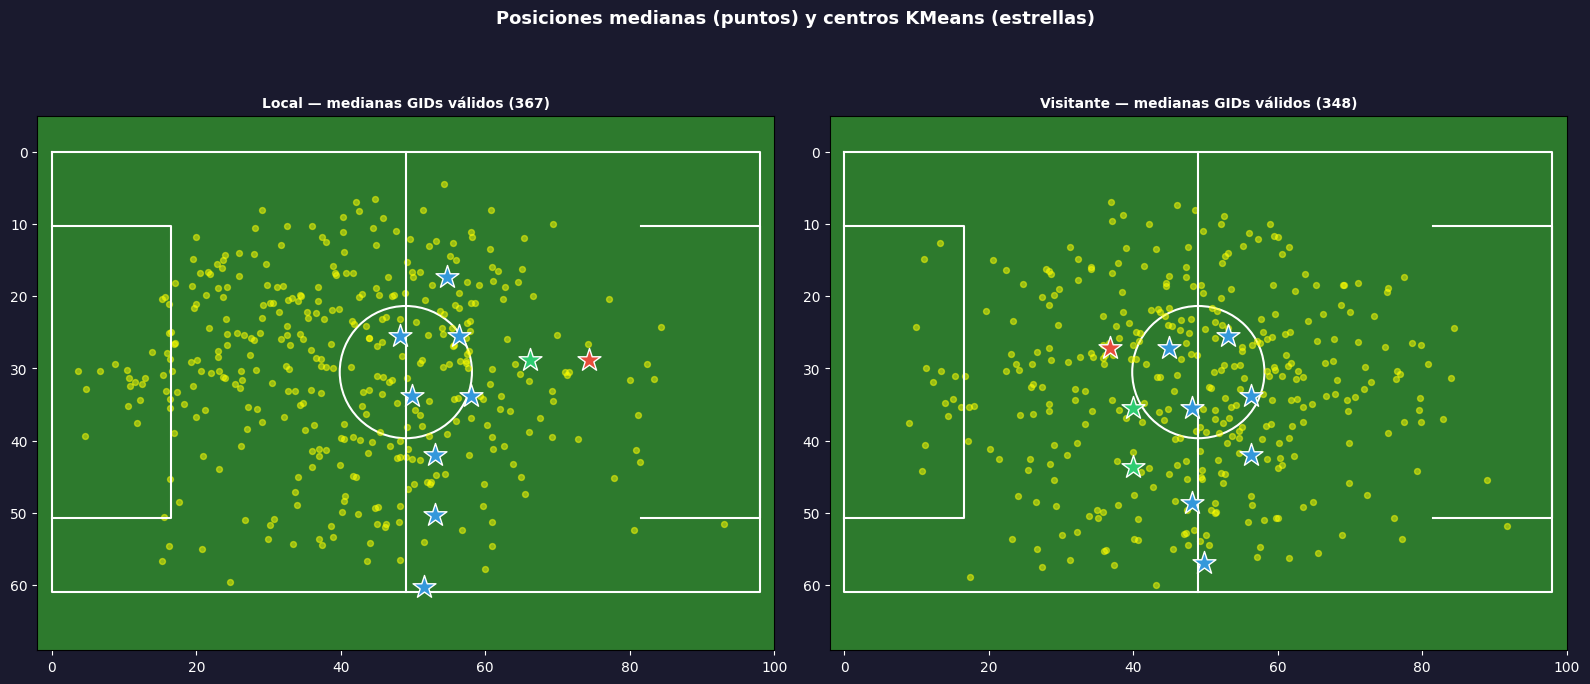

In [5]:
# ── Diagnóstico: scatter de posiciones medianas por GID (antes del KMeans) ─
def plot_medians(ax, df_team, team_cls, gk_cls, home_attacks_left,
                 halftime_frame, is_home, field_length, min_frames, title):
    from pipeline_core import _x_norm_series
    sub = df_team[df_team['cls'].isin(team_cls) & (df_team['cls'] != gk_cls)].copy()
    gid_counts = sub.groupby('gid')['frame'].nunique()
    valid = gid_counts[gid_counts >= min_frames].index
    sub = sub[sub['gid'].isin(valid)].copy()
    xn = _x_norm_series(sub['x_m'], sub['frame'],
                        is_home, home_attacks_left, halftime_frame, field_length)
    sub['x_norm_m'] = xn   # metros, 0=portería propia
    medians = sub.groupby('gid').agg(x_norm_m=('x_norm_m','median'),
                                      y_m=('y_m','median')).reset_index()
    # Convertir a coordenadas absolutas para plotear en el campo
    x_abs = medians['x_norm_m'].values if not is_home else medians['x_norm_m'].values
    # local ataca izquierda → x_abs = field_length - x_norm_m para mostrar en absoluto
    x_plot = (field_length - medians['x_norm_m'].values) if home_attacks_left and is_home \
              else medians['x_norm_m'].values
    ax.scatter(x_plot, medians['y_m'].values, s=18, alpha=0.5, color='yellow')
    ax.set_title(f'{title} — medianas GIDs válidos ({len(medians)})',
                 color='white', fontsize=10, fontweight='bold')


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    draw_pitch(ax)
    ax.tick_params(colors='white')

plot_medians(axes[0], df, ['player_home','gk_home'], 'gk_home',
             HOME_ATTACKS_LEFT, HALFTIME_FRAME, True, L_M, MIN_FRAMES, 'Local')
plot_medians(axes[1], df, ['player_away','gk_away'], 'gk_away',
             HOME_ATTACKS_LEFT, HALFTIME_FRAME, False, L_M, MIN_FRAMES, 'Visitante')

# Superponer centros KMeans
for ax, centers, invert in [(axes[0], centers_home, False), (axes[1], centers_away, True)]:
    if centers.empty: continue
    x_m = (1 - centers['x_norm'].values if invert else centers['x_norm'].values) * L_M
    for i, (xi, yi, line) in enumerate(zip(x_m, centers['y_m'], centers['line'])):
        ax.scatter(xi, yi, s=300, color=LINE_COLORS[int(line)%4],
                   marker='*', edgecolors='white', linewidths=1, zorder=6)

plt.suptitle('Posiciones medianas (puntos) y centros KMeans (estrellas)',
             fontsize=13, color='white', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()